In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Revised to use helper_gpt + main_gpt2 outputs while preserving plot styling.
"""

colors_selected=[ "#2ca02c","#9467bd","#ff7f0e"]

import json
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import tensorflow as tf
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import matplotlib.patches as patches

sys.path.insert(0, str(Path("..").resolve()))
import src.helper_gpt as helper_gpt

# Set global font size
plt.rcParams.update({'font.size': 16})
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

# ---------------------------------------------------------------------
# User-facing configuration
# ---------------------------------------------------------------------
save_dir = Path("../runs_em1")
strength_dir = "../../dipoles_data_all/total_strength/"
alphaD_dir = "../../dipoles_data_all/total_alphaD/"
strength_regex = r"strength_(?P<p2>[0-9.]+)_(?P<p1>[0-9.]+)\.out"
alphaD_regex = None

# If None, use the value stored in run_summary.json.
retain_override = None

# Indices of spectra highlighted in panel (b)
idx = [46, 3, 176]

# ---------------------------------------------------------------------
# Load trained emulator metadata and dataset
# ---------------------------------------------------------------------
with open(save_dir / "run_summary.json", "r") as f:
    run_summary = json.load(f)

config_dict = run_summary["config"]
args_dict = run_summary["args"]

n = int(config_dict["n"])
retain = float(args_dict["retain"] if retain_override is None else retain_override)

config = helper_gpt.AnsatzConfig(
    n=n,
    n_params=int(config_dict["n_params"]),
    ansatz=config_dict["ansatz"],
    width_model=config_dict["width_model"],
    use_vector_terms=bool(config_dict["use_vector_terms"]),
)

params = np.loadtxt(save_dir / "best_params_global.txt").astype(np.float32)

all_dataset = helper_gpt.load_dataset(
    strength_dir=strength_dir,
    alphaD_dir=alphaD_dir,
    strength_regex=strength_regex,
    alphaD_regex=alphaD_regex,
    filter_ranges=None,
    central_point=run_summary["central_point"],
)

param_names = list(all_dataset.param_names)
param_values = np.asarray(all_dataset.param_values, dtype=np.float32)
central_point = np.asarray(run_summary["central_point"], dtype=np.float32)

# Train-set points are saved explicitly by main_gpt2.py
train_param_values = np.loadtxt(save_dir / "train_param_values.txt")
train_param_values = np.atleast_2d(train_param_values).astype(np.float32)

# Optional test-set points are also saved, but not required here
test_param_path = save_dir / "test_param_values.txt"
if test_param_path.exists():
    test_param_values = np.loadtxt(test_param_path)
    test_param_values = np.atleast_2d(test_param_values).astype(np.float32)
else:
    test_param_values = None

print("Loaded helper:", Path(helper_gpt.__file__).resolve())
print("Parameter names:", param_names)
print("Central point:", central_point.tolist())
print("Run config:", helper_gpt.summarize_config(config))
print("Samples in full dataset:", len(all_dataset.strengths))
print("Samples in train set:", len(train_param_values))


Loaded helper: /Users/laurenjin/Documents/projects/SMLR-param_dev/SMLR/Dipole_polarizability/src/helper_gpt.py
Parameter names: ['p1', 'p2']
Central point: [1.100000023841858, 2.75]
Run config: {'n': 13, 'n_params': 2, 'ansatz': 'linear_exp', 'width_model': 'affine', 'use_vector_terms': True, 'n_basis': 4, 'n_upper': 91, 'n_trainable': 422}
Samples in full dataset: 225
Samples in train set: 110


<>:170: SyntaxWarning: invalid escape sequence '\o'
<>:170: SyntaxWarning: invalid escape sequence '\o'
/var/folders/jb/056vg5td3x140pfzlhf0s5hr0000gn/T/ipykernel_63049/2842090947.py:170: SyntaxWarning: invalid escape sequence '\o'
  ax[1].set_ylabel('$S(\omega)$ (fm${}^{2}$/MeV)', size=22)
2026-04-09 00:29:49.864437: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at einsum_op_impl.h:508 : INVALID_ARGUMENT: Expected dimension 6 at axis 1 of the input shaped [225,13] but got dimension 13
2026-04-09 00:29:49.865152: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INVALID_ARGUMENT: Expected dimension 6 at axis 1 of the input shaped [225,13] but got dimension 13
/var/folders/jb/056vg5td3x140pfzlhf0s5hr0000gn/T/ipykernel_63049/2842090947.py:170: SyntaxWarning: invalid escape sequence '\o'
  ax[1].set_ylabel('$S(\omega)$ (fm${}^{2}$/MeV)', size=22)


InvalidArgumentError: {{function_node __wrapped__Einsum_N_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Expected dimension 6 at axis 1 of the input shaped [225,13] but got dimension 13 [Op:Einsum] name: 

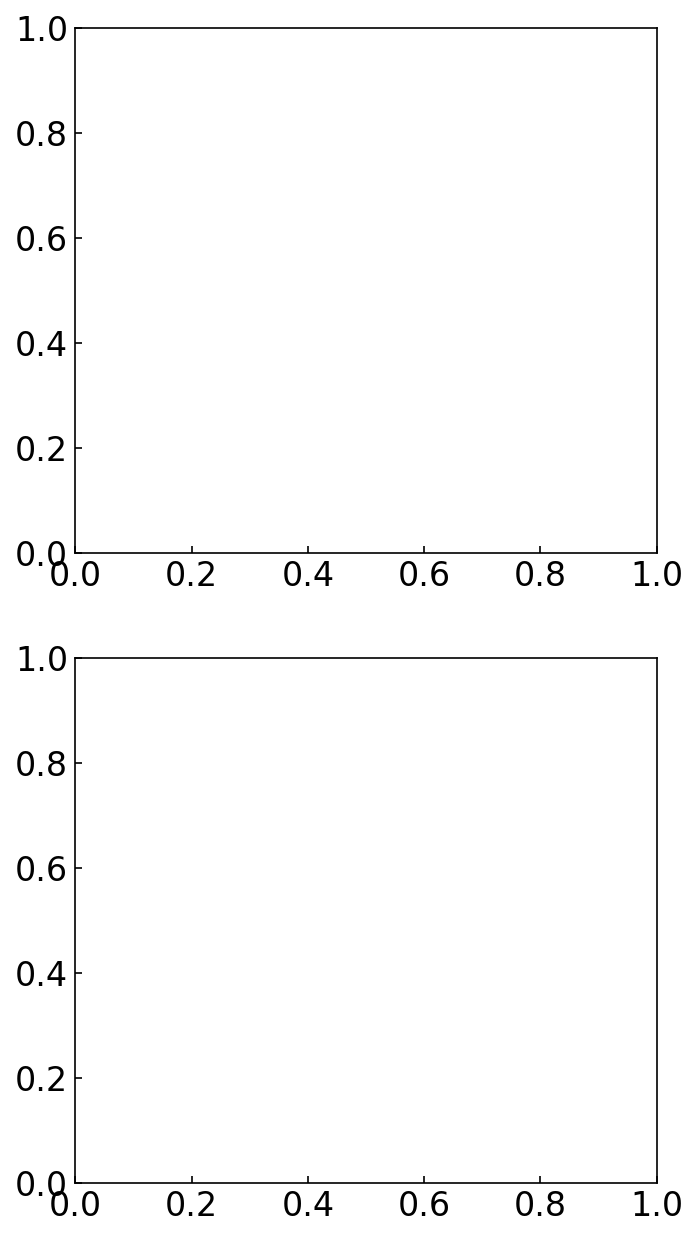

In [5]:
fig, ax = plt.subplots(2, 1, dpi=150, figsize=(5, 10))

# ---------------------------------------------------------------------
# Reconstruct emulator predictions on the full dataset using helper_gpt
# ---------------------------------------------------------------------
param_values_tf = tf.convert_to_tensor(param_values, dtype=tf.float32)
central_point_tf = tf.convert_to_tensor(central_point, dtype=tf.float32)
params_tf = tf.convert_to_tensor(params, dtype=tf.float32)

M_batch, v_batch, eta_batch, _ = helper_gpt.build_model_matrices_and_vectors(
    params=params_tf,
    config=config,
    param_values=param_values_tf,
    central_point=central_point_tf,
)

eigenvalues_all, eigenvectors_all = tf.linalg.eigh(M_batch)

n_i = int(eigenvalues_all.shape[1])
k_keep = int(round(retain * n_i))
k_keep = max(1, min(k_keep, n_i))
left = (n_i - k_keep) // 2
right = left + k_keep

opt_eigs_tf = eigenvalues_all[:, left:right]
opt_vecs_tf = eigenvectors_all[:, :, left:right]

proj_tf = tf.einsum('bij,bi->bj', tf.transpose(opt_vecs_tf, perm=[0, 2, 1]), v_batch)
B_tf = tf.square(proj_tf)

mask_tf = tf.cast(opt_eigs_tf > 1.0, tf.float32)
opt_Bs_tf = B_tf * mask_tf

omega = np.asarray(all_dataset.strengths[0][:, 0], dtype=np.float32)
opt_strength_tf = helper_gpt.give_me_Lorentzian_batched(
    omega[None, :], opt_eigs_tf, opt_Bs_tf, eta_batch / 2.0
)

alphaD_opt_tf = tf.reduce_sum(
    opt_Bs_tf / tf.maximum(opt_eigs_tf, 1.0e-6), axis=1
) * tf.constant(helper_gpt.ALPHAD_FAC, dtype=tf.float32)

opt_strength = opt_strength_tf.numpy()
opt_eigs = opt_eigs_tf.numpy()
opt_Bs = opt_Bs_tf.numpy()
alphaD_opt = alphaD_opt_tf.numpy()

orig_strength = all_dataset.strengths
combined = [tuple(map(float, row)) for row in param_values]

# ---------------------------------------------------------------------
# Relative L2 error on strength S(omega)
# ---------------------------------------------------------------------
x_vals = [pt[0] for pt in combined]
y_vals = [pt[1] for pt in combined]

rel_L2 = np.empty(len(combined), dtype=float)

for k, (S_hat_k, true_pair_k) in enumerate(zip(opt_strength, orig_strength)):
    E = np.asarray(true_pair_k[:, 0], dtype=np.float64)
    S_true = np.asarray(true_pair_k[:, 1], dtype=np.float64)
    S_hat = np.asarray(S_hat_k, dtype=np.float64)

    num = np.trapz((S_hat - S_true) ** 2, E)
    den = np.trapz((S_true) ** 2, E)
    rel_L2[k] = num / den if den > 0 else np.nan

mask = np.isfinite(rel_L2)
c_vals = np.clip(rel_L2[mask], 1e-16, None)
x_plot = np.asarray(x_vals)[mask]
y_plot = np.asarray(y_vals)[mask]

im = ax[0].scatter(
    x_plot, y_plot, c=c_vals, marker='o',
    cmap='coolwarm', norm=LogNorm(),
    edgecolors='0.3', linewidths=0.6, s=170
)
ax[0].scatter(
    x_plot, y_plot, marker='.',
    color='black', norm=LogNorm(),
    edgecolors='0.3', linewidths=0.6
)

cbar_ax = fig.add_axes([0.92, 0.55, 0.02, 0.3])
cbar = fig.colorbar(im, cax=cbar_ax)
t = cbar.ax.set_title(r"$\chi^2_{S(i)}$", fontsize=16, pad=6)
t.set_x(1.22)

# ---------------------------------------------------------------------
# Shaded training region
# ---------------------------------------------------------------------
train_alpha = train_param_values[:, 0]
train_beta = train_param_values[:, 1]

alpha_min = float(np.min(train_alpha))
alpha_max = float(np.max(train_alpha))
beta_min = float(np.min(train_beta))
beta_max = float(np.max(train_beta))

ux = np.unique(np.round(np.asarray(x_vals, float), 6))
uy = np.unique(np.round(np.asarray(y_vals, float), 6))
dx = np.min(np.diff(ux)) if ux.size > 1 else 0.0
dy = np.min(np.diff(uy)) if uy.size > 1 else 0.0
pad_x = 0.5 * dx
pad_y = 0.5 * dy

xmin = alpha_min - pad_x
xmax = alpha_max + pad_x
ymin = beta_min - pad_y
ymax = beta_max + pad_y

x_lo, x_hi = ax[0].get_xlim()
y_lo, y_hi = ax[0].get_ylim()
xmin = max(xmin, x_lo)
xmax = min(xmax, x_hi)
ymin = max(ymin, y_lo)
ymax = min(ymax, y_hi)

face_rgba = mcolors.to_rgba('0.6', 0.30)
fill = patches.Rectangle(
    (xmin, ymin), xmax - xmin, ymax - ymin,
    facecolor=face_rgba, edgecolor='none', zorder=0.5
)
edge = patches.Rectangle(
    (xmin, ymin), xmax - xmin, ymax - ymin,
    facecolor='none', edgecolor='k', linewidth=2.2, zorder=0.6
)
ax[0].add_patch(fill)
ax[0].add_patch(edge)

ax[0].set_xlabel('$d_{TV}$', size=22)
ax[0].set_ylabel('$b_{TV}$ (fm${}^{2}$)', size=22)

# ---------------------------------------------------------------------
# Example spectra panel
# ---------------------------------------------------------------------
for i in range(len(idx)):
    alpha = float(combined[idx[i]][0])
    beta = float(combined[idx[i]][1])

    ax[0].scatter(
        alpha, beta, ec=colors_selected[i],
        s=300, fc='none', linewidths=3.5
    )

    x = orig_strength[idx[i]][:, 0]

    ax[1].plot(
        x, opt_strength[idx[i]], color='black',
        ls='--', lw=2.5, alpha=0.9, zorder=99
    )
    ax[1].plot(
        x, orig_strength[idx[i]][:, 1], lw=3,
        label=rf"$d_{{TV}}={alpha:.2f},\ b_{{TV}}={beta:.2f}\ \mathrm{{fm}}^{{-2}}$",
        color=colors_selected[i]
    )

ax[1].set_ylim(0)
ax[1].set_xlim(np.min(x), np.max(x))
leg = ax[1].legend(
    frameon=False, fontsize=11.3,
    loc='upper left',
    bbox_to_anchor=(0.34, 1.0),
    handlelength=1.2,
    handletextpad=0.6,
    labelspacing=0.3
)

ax[1].set_xlabel(r'$\omega$ (MeV)', size=22)
ax[1].set_ylabel('$S(\omega)$ (fm${}^{2}$/MeV)', size=22)

ax[0].annotate('(a)', (-0.25, 1.02), xycoords='axes fraction', size=24)
ax[1].annotate('(b)', (-0.25, 1.02), xycoords='axes fraction', size=24)
ax[1].annotate('${}^{180}$Yb', (0.7, 0.5), xycoords='axes fraction', size=26)

plt.subplots_adjust(hspace=0.25)

ax[1].xaxis.set_minor_locator(ticker.MultipleLocator(2))
ax[1].yaxis.set_minor_locator(ticker.MultipleLocator(1))

# plt.savefig('YbPerformance.pdf', bbox_inches='tight')
plt.show()
